In [1]:
import healpy
import healpy as hp
from jax_healpy import pixelfunc as jhp
import numpy as np
import jax
import jax.numpy as jnp
import jax.nn as jnn
import optax
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import hera_filters as hf
from functools import partial
import scipy
jax.config.update("jax_enable_x64", True)


dtype_r = jnp.float64
DEFAULT_NSIDE = 32
DEFAULT_NPIX = healpy.nside2npix(DEFAULT_NSIDE)
px = jnp.arange(DEFAULT_NPIX)
th, phi = healpy.pix2ang(DEFAULT_NSIDE, px)
DEFAULT_BEAM_TH = jnp.cos(th)**2 * jnp.cos(phi)**2
DEFAULT_BEAM_PHI = jnp.cos(th)**2 * jnp.sin(phi)**2
save_path = '/Users/dominiv/sfsu/thesis/figures/'

In [2]:
from datetime import datetime, timezone
from zoneinfo import ZoneInfo
import os
mtn_tzone = ZoneInfo("America/Denver")

t_start = datetime(2025, 7, 20, 13, 11, 51, 774738, tzinfo=mtn_tzone)
t_stop =  datetime(2025, 7, 20, 14, 35, 41, 181442, tzinfo=mtn_tzone)
def unix_time_to_local(unix_times):
    local_times = np.array([datetime.fromtimestamp(ts, tz=timezone.utc).astimezone(mtn_tzone) for ts in unix_times])
    return local_times

In [3]:
npz_file = '/Users/dominiv/eigsep/data/all_ant_2.npz'
# dtype_r = np.float32
dtype_c = np.complex64
if not os.path.exists(npz_file):
    data = {}
    times = []
    for f in files:
        print(f)
        hdr = read_header(f)
        if unix_time_to_local(hdr['times'][-1:]) < t_start:
            continue
        if unix_time_to_local(hdr['times'][:1]) > t_stop:
            continue
        dat, hdr, meta = io.read_hdf5(f)
        times.append(hdr['times'])
        for k in dat.keys():
            _d = dat[k]
            data[k] = data.get(k, []) + [_d]
    for k, v in data.items():
        data[k] = np.concatenate(v, dtype=dtype_r if len(k) == 1 else dtype_c)
    times = np.concatenate(times)
    local_times = unix_time_to_local(times)
    np.savez(npz_file, times=times, local_times=local_times, freqs=freqs, **data)
else:
    npz = np.load(npz_file, allow_pickle=True)
    data = {k: npz[k] for k in npz.files}
    times = data.pop('times')
    local_times = data.pop('local_times')
    freqs = data.pop('freqs')

In [4]:
chs = np.arange(16, 1024, 16)
k_1 = '2'
reduced = data[k_1][:, chs]
reduced = data[k_1][:,chs] - 0.5 * (data[k_1][:,chs-1] + data[k_1][:,chs+1])
f_ind = 44
# f_ind = 52
# f_ind = 61
ch = f_ind
AZ_STEPS = 72  # with endpoint=True
period = 68.78
#t_start = 1753038750 # s utc
t_start = 1753038750 + period/2 # s utc
# t_start = times[0] + period/2 # s utc
t_cut = [(1753039060, 1753039181), (1753042808, 1753042834), (1753043111, 1753043119)]  # junk data
i_start = np.searchsorted(times, t_start)
norm = 1 / np.mean(reduced[:i_start], axis=0, keepdims=True)
norm[:,:4] = 0
t_stop = t_start + AZ_STEPS * period
i_stop = np.searchsorted(times, t_stop)

valid = np.ones(times.shape, dtype=bool)
valid = np.where(reduced[:,52] * norm[:,52] < 1e-4, False, ~np.isnan(reduced[:,52]))
for ti, tj in t_cut:
    i, j = np.searchsorted(times, ti), np.searchsorted(times, tj)
    valid[i:j] = False
    
valid[1:-1] = np.logical_and(valid[1:-1], np.logical_and(valid[:-2], valid[2:]))
sl = slice(i_start, i_stop)
_times = times[sl].copy()
_times -= _times[0]
# optional for strictly data-driven double-period folding
#_times_rnd = np.floor(_times / (2 * period))
#_times_mod = _times - _times_rnd * (2 * period)
val = valid[sl]
print(freqs[::16][ch])

171.875


In [5]:
import aipy
class BeamFit:
    def __init__(self, times, az_steps=AZ_STEPS, lmax=5):
        self.az_steps = az_steps
        self.times = times
        self.lmax = lmax
        self._el_ax = self._ant_pvec = np.array([1, 0, 0], dtype=dtype_r)
        self._az_ax = np.array([0, 0, -1], dtype=dtype_r)
        self.prms = {}
        self.ant_pvec = self.polresp = self.A_Ylm = self.A = None

    def _set_timing_params(self, prms):
        keys = {'t_off', 'el_off', 't_az_step', 'period'}
        for k in keys:
            if k in prms and prms[k] != self.prms.get(k, None):
                self.prms[k] = prms[k]
                self.az_deg = self.el_deg = self.ant_pvec = self.A_Ylm = self.A = None

    def _set_pol_params(self, prms):
        keys = {'prz', 'px', 'py'}
        for k in keys:
            if k in prms and prms[k] != self.prms.get(k, None):
                self.prms[k] = prms[k]
                self.gnd_pvecs = self.polresp = self.A = None

    def set_params(self, prms):
        self._set_timing_params(prms)
        self._set_pol_params(prms)
        
    def build_az_el(self):
        '''Build az/el coordinates.'''
        if self.ant_pvec is not None:
            return
        az, el, inds = [], [], []
        t_off, el_off, t_az_step, period = self.prms['t_off'], self.prms['el_off'], self.prms['t_az_step'], self.prms['period']
        i = 0
        t_i = self.times[0] + t_off
        for cnt, _az in enumerate(np.linspace(-180, 180, self.az_steps, endpoint=True)):
            t_f = t_i + period
            while i < self.times.size and self.times[i] < t_f - t_az_step:
                az.append(_az)
                if cnt % 2 == 0:
                    el.append(-180 + 360 * (self.times[i] - t_i) / (period - t_az_step))
                else:
                    el.append( 180 - 360 * (self.times[i] - t_i) / (period - t_az_step))
                inds.append(i)
                i += 1
            while i < self.times.size and self.times[i] < t_f:
                az.append(_az + (360 / (self.az_steps - 1)) * (self.times[i] - (t_f - t_az_step))/t_az_step)
                el.append(el[-1])
                inds.append(i)
                i += 1
            t_i = t_f
        self.az_deg = np.array(az)
        self.el_deg = np.array(el) + el_off
        self.inds = np.array(inds)
        rot_az = aipy.coord.rot_m(np.deg2rad(self.az_deg), self._az_ax)
        rot_el = aipy.coord.rot_m(np.deg2rad(self.el_deg), self._el_ax)
        self.ant_pvec = np.einsum('pab,pbc,c->pa', rot_el, rot_az, self._ant_pvec)

    


    
    def build_pol_resp(self):
        self.build_az_el()
        if self.polresp is not None:
            return
        pvec = np.array([[self.prms['px'], 0, 0], [0, self.prms['py'], 0]], dtype=dtype_r)
        rot_m = aipy.coord.rot_m(np.deg2rad(self.prms['prz']), np.array([0, 0, 1])).astype(dtype_r)
        self.gnd_pvecs = np.dot(rot_m, pvec.T).T
        if self.gnd_pvecs.ndim == 1:
            self.gnd_pvecs = self.gnd_pvecs[None, :]
        resp = np.dot(self.ant_pvec, self.gnd_pvecs.T)
        self.polresp = np.sum(np.abs(resp)**2, axis=-1)

    def build_A_Ylm(self):
        self.build_az_el()
        if self.A_Ylm is not None:
            return
        phi = np.deg2rad(self.az_deg)
        theta = np.deg2rad(self.el_deg)
        theta = np.mod(theta, 2*np.pi)
        theta = np.where(theta > np.pi, 2*np.pi - theta, theta)
        phi = np.mod(phi, 2*np.pi)
    
        N = theta.size
        P = (self.lmax + 1)**2
        A = np.empty((N, P), dtype=dtype_r)
    
        # Keep track of which column corresponds to which (l,m,kind)
        # kind ∈ {'m0','c','s'} for m=0, cos-like, sin-like
        self._meta = []
        col = 0
        for ell in range(self.lmax + 1):
            # m = 0 term (purely real)
            Y_l0 = sph_harm(0, ell, phi, theta).real
            #Y_l0 *= gen_pol_resp(az_deg, el_deg, gnd_pvecs)
            A[:, col] = Y_l0
            self._meta.append((ell, 0, 'm0'))
            col += 1
    
            # m > 0 terms: sqrt(2)*Re and sqrt(2)*Im
            for m in range(1, ell + 1):
                Y_lm = sph_harm(m, ell, phi, theta)  # complex
                #Y_lm *= gen_pol_resp(az_deg, el_deg, gnd_pvecs)
                A[:, col] = SQRT2 * Y_lm.real
                A[:, col+1] = SQRT2 * Y_lm.imag
                self._meta.append((ell, m, 'c'))
                self._meta.append((ell, m, 's'))
                col += 2
    
        assert col == P
        self.A_Ylm = A

    def build_A(self):
        self.build_pol_resp()
        self.build_A_Ylm()
        if self.A is not None:
            return
        self.A = self.A_Ylm * self.polresp[:, None]

    def _realcoeff_to_alm(self, coeff):
        """
        Convert real-basis coeffficients (matching design-matrix columns) into a
        healpy alm array (complex, m>=0). For a real sky, alms obey:
          a_{l,-m} = (-1)^m a_{l m}^*
        We only fill m>=0 as healpy expects.
        """
        alm = np.zeros(Alm.getsize(self.lmax), dtype=dtype_c)
        for k, (ell, m, kind) in enumerate(self._meta):
            if m == 0 and kind == 'm0':
                alm[Alm.getidx(self.lmax, ell, 0)] = coeff[k]
            elif kind in ('c'):
                c = coeff[k]
                s = coeff[k + 1]
                a_lm = (c - 1j * s) / SQRT2
                alm[Alm.getidx(self.lmax, ell, m)] = a_lm
        return alm

    def fit_alms(self, ymeas, w=None, reg=None, rcond=1e-10):
        self.build_A()
    
        # Apply weights (as sqrt weights on rows)
        ymeas = ymeas[self.inds]
        if w is None:
            w = np.ones_like(ymeas)
        else:
            w = w[self.inds]
        sqrtw = np.sqrt(w)
        Aw = self.A * sqrtw[:, None]
        yw = ymeas * sqrtw
    
        # Optional ridge regularization: stack sqrt(reg)*I
        if reg is not None and reg > 0:
            P = self.A.shape[1]
            Aw = np.vstack([Aw, np.sqrt(reg) * np.eye(P)])
            yw = np.concatenate([yw, np.zeros(P)])
    
        coeff = np.linalg.lstsq(Aw[self.inds], yw[self.inds], rcond=rcond)[0]
        yhat = self.A @ coeff
        chisq = np.sum(w * (ymeas[self.inds] - yhat[self.inds])**2)
        alm = self._realcoeff_to_alm(coeff)
        return alm, chisq, yhat

In [6]:
t_az_step = 1.7
prms = dict(
    t_az_step = t_az_step, # XXX degenerate with beam width, need empirical measurement
    t_off = -2.4 + t_az_step/2,
    # t_off = -2.0 + t_az_step/2,
    el_off = -4.0,  # shift for pol_ang=62 on ch=44, seems to work for the rest. XXX degenerate with t_off?
    # el_off = -8.5,  # shift for pol_ang=62 on ch=44, seems to work for the rest. XXX degenerate with t_off?
    # az_off is unnecessary given fitting of polarization angle
    prz = 0.0,
    px = 1.0,
    py = 0.0,
    period = period,
)

# # force a rebuild
# fitter.ant_pvec = None
# fitter.az_deg = None
# fitter.el_deg = None
# fitter.A_Ylm = None
# fitter.A = None
# fitter.build_az_el()

fitter = BeamFit(_times[val])
fitter.set_params(prms)
fitter.build_az_el()
az_inds = np.deg2rad(fitter.az_deg[fitter.inds])
el_inds = np.deg2rad(fitter.el_deg[fitter.inds])

In [7]:
shift = 12
rot = reduced[:, shift:][sl][val][fitter.inds] #* norm[:, ch]
norm = norm[:, shift:]
outfile = 'figures/'
print(rot.shape, norm.shape)

(4409, 51) (1, 51)


In [8]:
rot_times = times[sl][val][fitter.inds]
rot_freq = freqs[chs[shift:]]
rot_freq.shape

(51,)

In [9]:
beam_maps_th = np.load('/Users/dominiv/eigsep/data/beam_th.npy')[:-1, :] # recent note: we go from 50 to 250, but the channels we actually use are from 50 tp 247ish, so we need to shave off the last channel
beam_maps_ph = np.load('/Users/dominiv/eigsep/data/beam_ph.npy')[:-1, :] # recent note: we go from 50 to 250, but the channels we actually use are from 50 tp 247ish, so we need to shave off the last channel
# gain_maps = beam_maps_th + beam_maps_ph
# empty_beam = jnp.full_like(DEFAULT_BEAM_PHI, hp.UNSEEN)

In [185]:
nside = DEFAULT_NSIDE
npix = DEFAULT_NPIX
bowtie_xr_gain_78 = np.loadtxt('/Users/dominiv/research/data/ElectricPatterns/Re_Ex_78.125MHz.csv', delimiter=',', skiprows=1)
bowtie_xi_gain_78 = np.loadtxt('/Users/dominiv/research/data/ElectricPatterns/Im_Ex_78.125MHz.csv', delimiter=',', skiprows=1)
bowtie_yr_gain_78 = np.loadtxt('/Users/dominiv/research/data/ElectricPatterns/Re_Ey_78.125MHz.csv', delimiter=',', skiprows=1)
bowtie_yi_gain_78 = np.loadtxt('/Users/dominiv/research/data/ElectricPatterns/Im_Ey_78.125MHz.csv', delimiter=',', skiprows=1)
bowtie_zr_gain_78 = np.loadtxt('/Users/dominiv/research/data/ElectricPatterns/Re_Ez_78.125MHz.csv', delimiter=',', skiprows=1)
bowtie_zi_gain_78 = np.loadtxt('/Users/dominiv/research/data/ElectricPatterns/Im_Ez_78.125MHz.csv', delimiter=',', skiprows=1)

bowtie_xr_gain_101 = np.loadtxt('/Users/dominiv/research/data/ElectricPatterns/Re_Ex_101.5625MHz.csv', delimiter=',', skiprows=1)
bowtie_xi_gain_101 = np.loadtxt('/Users/dominiv/research/data/ElectricPatterns/Im_Ex_101.5625MHz.csv', delimiter=',', skiprows=1)
bowtie_yr_gain_101 = np.loadtxt('/Users/dominiv/research/data/ElectricPatterns/Re_Ey_101.5625MHz.csv', delimiter=',', skiprows=1)
bowtie_yi_gain_101 = np.loadtxt('/Users/dominiv/research/data/ElectricPatterns/Im_Ey_101.5625MHz.csv', delimiter=',', skiprows=1)
bowtie_zr_gain_101 = np.loadtxt('/Users/dominiv/research/data/ElectricPatterns/Re_Ez_101.5625MHz.csv', delimiter=',', skiprows=1)
bowtie_zi_gain_101 = np.loadtxt('/Users/dominiv/research/data/ElectricPatterns/Im_Ez_101.5625MHz.csv', delimiter=',', skiprows=1)

bowtie_xr_gain_140 = np.loadtxt('/Users/dominiv/research/data/ElectricPatterns/Re_Ex_140.625MHz.csv', delimiter=',', skiprows=1)
bowtie_xi_gain_140 = np.loadtxt('/Users/dominiv/research/data/ElectricPatterns/Im_Ex_140.625MHz.csv', delimiter=',', skiprows=1)
bowtie_yr_gain_140 = np.loadtxt('/Users/dominiv/research/data/ElectricPatterns/Re_Ey_140.625MHz.csv', delimiter=',', skiprows=1)
bowtie_yi_gain_140 = np.loadtxt('/Users/dominiv/research/data/ElectricPatterns/Im_Ey_140.625MHz.csv', delimiter=',', skiprows=1)
bowtie_zr_gain_140 = np.loadtxt('/Users/dominiv/research/data/ElectricPatterns/Re_Ez_140.625MHz.csv', delimiter=',', skiprows=1)
bowtie_zi_gain_140 = np.loadtxt('/Users/dominiv/research/data/ElectricPatterns/Im_Ez_140.625MHz.csv', delimiter=',', skiprows=1)

bowtie_xr_gain_187 = np.loadtxt('/Users/dominiv/research/data/ElectricPatterns/Re_Ex_187.5MHz.csv', delimiter=',', skiprows=1)
bowtie_xi_gain_187 = np.loadtxt('/Users/dominiv/research/data/ElectricPatterns/Im_Ex_187.5MHz.csv', delimiter=',', skiprows=1)
bowtie_yr_gain_187 = np.loadtxt('/Users/dominiv/research/data/ElectricPatterns/Re_Ey_187.5MHz.csv', delimiter=',', skiprows=1)
bowtie_yi_gain_187 = np.loadtxt('/Users/dominiv/research/data/ElectricPatterns/Im_Ey_187.5MHz.csv', delimiter=',', skiprows=1)
bowtie_zr_gain_187 = np.loadtxt('/Users/dominiv/research/data/ElectricPatterns/Re_Ez_187.5MHz.csv', delimiter=',', skiprows=1)
bowtie_zi_gain_187 = np.loadtxt('/Users/dominiv/research/data/ElectricPatterns/Im_Ez_187.5MHz.csv', delimiter=',', skiprows=1)

dipole_theta_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_THETA_150MHz.csv', delimiter=',', skiprows=1)
dipole_phi_gain_150 = np.loadtxt('/Users/dominiv/research/data/complex/Realized_Gain_Patterns_Dipole_LinearScale/RGP_PHI_150MHz.csv', delimiter=',', skiprows=1)
beam_thetas_d = np.deg2rad(dipole_theta_gain_150[:, 1])
beam_phis_d =   np.deg2rad(dipole_theta_gain_150[:, 0])
def hfss_map_d(gain, k=8):
    sample_vec = np.asarray(hp.ang2vec(beam_thetas_d, beam_phis_d))
    if sample_vec.shape[0] == 3 and sample_vec.ndim == 2:
        sample_vec = sample_vec.T
    
    tree = cKDTree(sample_vec)
    
    pix_vec = np.asarray(hp.pix2vec(nside, np.arange(npix))).T
    
    # k = 8
    dist, idx = tree.query(pix_vec, k=k)
    
    if k == 1:
        dist = dist[:, None]
        idx = idx[:, None]
    
    eps = 1e-12
    w = 1.0 / (dist + eps)**2
    w /= w.sum(axis=1, keepdims=True)
    
    hmap = (w * gain[:, 2][idx]).sum(axis=1)
    return hmap


beam_thetas_ = np.deg2rad(bowtie_xr_gain_78[:, 1])
beam_phis_ =   np.deg2rad(bowtie_xr_gain_78[:, 0])
def hfss_map_(gain, k=8):
    sample_vec = np.asarray(hp.ang2vec(beam_thetas_, beam_phis_))
    if sample_vec.shape[0] == 3 and sample_vec.ndim == 2:
        sample_vec = sample_vec.T
    
    tree = cKDTree(sample_vec)
    
    pix_vec = np.asarray(hp.pix2vec(nside, np.arange(npix))).T
    
    # k = 8
    dist, idx = tree.query(pix_vec, k=k)
    
    if k == 1:
        dist = dist[:, None]
        idx = idx[:, None]
    
    eps = 1e-12
    w = 1.0 / (dist + eps)**2
    w /= w.sum(axis=1, keepdims=True)
    
    hmap = (w * gain[:, 2][idx]).sum(axis=1)
    return hmap
ek = 8
bowtie_xi_beam_78 = hfss_map_(bowtie_xi_gain_78, k=ek)
bowtie_xr_beam_78 = hfss_map_(bowtie_xr_gain_78, k=ek)
bowtie_yi_beam_78 = hfss_map_(bowtie_yi_gain_78, k=ek)
bowtie_yr_beam_78 = hfss_map_(bowtie_yr_gain_78, k=ek)
bowtie_zi_beam_78 = hfss_map_(bowtie_zi_gain_78, k=ek)
bowtie_zr_beam_78 = hfss_map_(bowtie_zr_gain_78, k=ek)

bowtie_xi_beam_101 = hfss_map_(bowtie_xi_gain_101, k=ek)
bowtie_xr_beam_101 = hfss_map_(bowtie_xr_gain_101, k=ek)
bowtie_yi_beam_101 = hfss_map_(bowtie_yi_gain_101, k=ek)
bowtie_yr_beam_101 = hfss_map_(bowtie_yr_gain_101, k=ek)
bowtie_zi_beam_101 = hfss_map_(bowtie_zi_gain_101, k=ek)
bowtie_zr_beam_101 = hfss_map_(bowtie_zr_gain_101, k=ek)

bowtie_xi_beam_140 = hfss_map_(bowtie_xi_gain_140, k=ek)
bowtie_xr_beam_140 = hfss_map_(bowtie_xr_gain_140, k=ek)
bowtie_yi_beam_140 = hfss_map_(bowtie_yi_gain_140, k=ek)
bowtie_yr_beam_140 = hfss_map_(bowtie_yr_gain_140, k=ek)
bowtie_zi_beam_140 = hfss_map_(bowtie_zi_gain_140, k=ek)
bowtie_zr_beam_140 = hfss_map_(bowtie_zr_gain_140, k=ek)


bowtie_xi_beam_187 = hfss_map_(bowtie_xi_gain_187, k=ek)
bowtie_xr_beam_187 = hfss_map_(bowtie_xr_gain_187, k=ek)
bowtie_yi_beam_187 = hfss_map_(bowtie_yi_gain_187, k=ek)
bowtie_yr_beam_187 = hfss_map_(bowtie_yr_gain_187, k=ek)
bowtie_zi_beam_187 = hfss_map_(bowtie_zi_gain_187, k=ek)
bowtie_zr_beam_187 = hfss_map_(bowtie_zr_gain_187, k=ek)


dipole_theta_beam_150 = hfss_map_d(dipole_theta_gain_150, k=ek)
dipole_phi_beam_150 = hfss_map_d(dipole_phi_gain_150, k=ek)

def tot_g(x, y, z):
    mu0 = 12.566e-7
    eps0 = 8.854e-12
    eta0 = jnp.sqrt(mu0 / eps0)
    Pinc = 1.0

    K_E = 4 * jnp.pi / (2 * eta0 * Pinc)
    mv_V = 1e-3
    return (jnp.abs(x*mv_V)**2 + jnp.abs(y*mv_V)**2 + jnp.abs(z*mv_V)**2) * K_E

rx_w_x78 = bowtie_xr_beam_78 + 1j*bowtie_xi_beam_78
rx_w_y78 = bowtie_yr_beam_78 + 1j*bowtie_yi_beam_78
rx_w_z78 = bowtie_zr_beam_78 + 1j*bowtie_zi_beam_78


rx_w_x101 = bowtie_xr_beam_101 + 1j*bowtie_xi_beam_101
rx_w_y101 = bowtie_yr_beam_101 + 1j*bowtie_yi_beam_101
rx_w_z101 = bowtie_zr_beam_101 + 1j*bowtie_zi_beam_101

rx_w_x140 = bowtie_xr_beam_140 + 1j*bowtie_xi_beam_140
rx_w_y140 = bowtie_yr_beam_140 + 1j*bowtie_yi_beam_140
rx_w_z140 = bowtie_zr_beam_140 + 1j*bowtie_zi_beam_140

rx_w_x187 = bowtie_xr_beam_187 + 1j*bowtie_xi_beam_187
rx_w_y187 = bowtie_yr_beam_187 + 1j*bowtie_yi_beam_187
rx_w_z187 = bowtie_zr_beam_187 + 1j*bowtie_zi_beam_187

E_tot78 = tot_g(rx_w_x78, rx_w_y78, rx_w_z78)
# E_tot = tot_g(rx_w_x, rx_w_y, rx_w_z)
all_gs = beam_maps_ph + beam_maps_th

0.01566167971472561


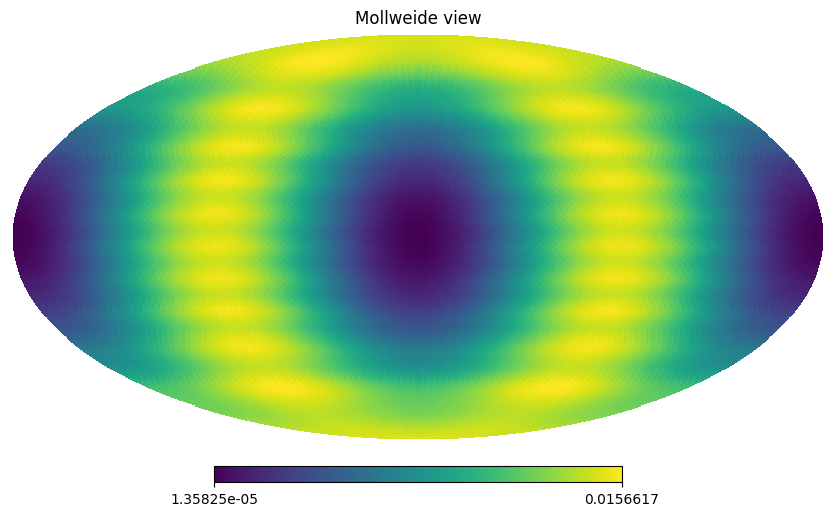

In [187]:
print(np.max(dipole_phi_beam_150 + dipole_theta_beam_150))
hp.mollview(dipole_theta_beam_150 + dipole_phi_beam_150)

In [17]:
def rot_m(ang, vec):
    """Return 3x3 matrix defined by rotation by 'ang' around the
    axis 'vec', according to the right-hand rule.  Both can be vectors,
    returning a vector of rotation matrices.  Rotation matrix will have a
    scaling of |vec| (i.e. normalize |vec|=1 for a pure rotation)."""
    c = jnp.cos(ang); s = jnp.sin(ang); C = 1-c
    # vec = vec/jnp.linalg.norm(vec, axis=-1, keepdims=True) # just added
    x,y,z = vec[...,0], vec[...,1], vec[...,2]
    xs,ys,zs = x*s, y*s, z*s
    xC,yC,zC = x*C, y*C, z*C
    xyC,yzC,zxC = x*yC, y*zC, z*xC
    rm = jnp.array([[x*xC+c, xyC-zs, zxC+ys],
                   [xyC+zs, y*yC+c, yzC-xs],
                   [zxC-ys, yzC+xs, z*zC+c]], dtype=jnp.double)
    if rm.ndim > 2:
        axes = list(range(rm.ndim))
        return rm.transpose(axes[-1:] + axes[:-1])
    else:
        return rm


def xyz2thphi(xyz, *, dtype=jnp.float64, return_mask=False, masked_fill=0.0):
    """
    Convert xyz vectors (x,y,z along first axis) into angles:
      theta (from +z), phi (counter-clockwise around +z, 0 at +x).

    - Accepts regular arrays or np.ma.MaskedArray.
    - If masked input is given (mask taken from x), masked elements are
      treated as `masked_fill` during the computation (default 0.0),
      which matches the original `.filled(0)` behavior.
    - Returns a JAX array shaped (2, ...): [theta, phi].
    - If `return_mask=True`, also returns a boolean mask shaped (2, ...),
      equal to [x.mask, x.mask] when a mask exists, else all False.
    """
    x, y, z = xyz

    # Detect masked arrays and normalize inputs
    x_is_ma = isinstance(x, np.ma.MaskedArray)
    if x_is_ma:
        # Use x's mask like the original function
        in_mask = jnp.asarray(getattr(x, "mask", False))
        # Compute with masked values filled as zeros (or masked_fill)
        x = np.ma.filled(x, masked_fill)
        y = np.ma.filled(y, masked_fill)
        z = np.ma.filled(z, masked_fill)
    else:
        in_mask = None

    # Convert to JAX arrays
    x = jnp.asarray(x)
    y = jnp.asarray(y)
    z = jnp.asarray(z)

    # More stable than sqrt(x**2 + y**2)
    r   = jnp.hypot(x, y)
    phi = jnp.arctan2(y, x)
    th  = jnp.arctan2(r, z)

    out = jnp.stack([th, phi]).astype(dtype)

    if return_mask:
        if in_mask is None:
            mask = jnp.zeros_like(x, dtype=bool)
        else:
            mask = jnp.asarray(in_mask, dtype=bool)
        # Propagate the mask to both rows: [x.mask, x.mask]
        mask = jnp.broadcast_to(mask, x.shape)
        mask = jnp.stack([mask, mask])
        return out, mask

    return out

def _sph_basis(th, phi):
    s, c   = jnp.sin(th), jnp.cos(th)
    sp, cp = jnp.sin(phi), jnp.cos(phi)
    r_hat   = jnp.stack([cp*s,  sp*s,  c], axis=-1)
    th_hat  = jnp.stack([cp*c,  sp*c, -s], axis=-1)
    phi_hat = jnp.stack([-sp,     cp,  jnp.zeros_like(th)], axis=-1)
    return r_hat, th_hat, phi_hat

DEFAULT_BEAM_X = jnp.copy(DEFAULT_BEAM_TH)
DEFAULT_BEAM_Y = jnp.copy(DEFAULT_BEAM_TH)
DEFAULT_BEAM_Z = jnp.copy(DEFAULT_BEAM_TH)


@jax.tree_util.register_pytree_node_class
class RotatingAntenna_comp_cart:
    # def __init__(self, beam_th=DEFAULT_BEAM_TH, beam_phi=DEFAULT_BEAM_PHI, 
    def __init__(self, beam_x=DEFAULT_BEAM_X, beam_y=DEFAULT_BEAM_Y, beam_z=DEFAULT_BEAM_Z,
                 el_ax=jnp.array([1, 0, 0], dtype=dtype_r),
                az_ax=jnp.array([0, 0, 1], dtype=dtype_r)):
        # self.pwr_beam_th  = jnp.asarray(beam_th)
        # self.pwr_beam_phi = jnp.asarray(beam_phi)
        self.pwr_beam_x  = jnp.asarray(beam_x)
        self.pwr_beam_y  = jnp.asarray(beam_y)
        self.pwr_beam_z  = jnp.asarray(beam_z)
        # healpy helper to get nside (static python int)
        self.nside = healpy.npix2nside(int(jnp.size(beam_x)))
        # rotation axes in your convention
        self.el_axis = el_ax
        self.az_axis = az_ax
        # self.el_axis = jnp.array([0, 1, 0], dtype=dtype_r)
        # self.az_axis = jnp.array([1, 0, 0], dtype=dtype_r)
        # NEW: per-instance switch (default off). Set True to use θ' = π − θ everywhere.
        self._theta_flip_to_data = False
        self.pvec = jnp.array([1, 0, 0])

    # ---- PyTree protocol (arrays as leaves; statics in aux) ----
    def tree_flatten(self):
        # leaves = (self.pwr_beam_th, self.pwr_beam_phi, self.el_axis, self.az_axis)
        leaves = (self.pwr_beam_x, self.pwr_beam_y, self.pwr_beam_z, self.el_axis, self.az_axis)
        aux = (self.nside, self._theta_flip_to_data)
        return leaves, aux

    @classmethod
    def tree_unflatten(cls, aux, leaves):
        nside, theta_flip = aux
        # pwr_beam_th, pwr_beam_phi, el_axis, az_axis = leaves
        pwr_beam_x, pwr_beam_y, pwr_beam_z, el_axis, az_axis = leaves
        # obj = cls(pwr_beam_th, pwr_beam_phi)
        obj = cls(pwr_beam_x, pwr_beam_y, pwr_beam_z)
        object.__setattr__(obj, "nside", int(nside))
        object.__setattr__(obj, "el_axis", el_axis)
        object.__setattr__(obj, "az_axis", az_axis)
        object.__setattr__(obj, "_theta_flip_to_data", bool(theta_flip))
        return obj


    def rotation(self, az, el): ### Added
        xg = self.el_axis
        zg = self.az_axis
        # xg = jnp.array([0.0, 1.0, 0.0]) ## best
        # zg = jnp.array([0.0, 0.0, 1.0]) ## best
        # xg = jnp.array([1.0, 0.0, 0.0]) ## best
        # zg = jnp.array([0.0, 0.0, 1.0]) ## best
    
        R_az = rot_m(az, zg)   # about global Z
        R_el = rot_m(el, xg)   # about global X
    
        # apply az first, then el (rightmost happens first)
        return (R_el @ R_az) ### Added
        # return (R_az @ R_el).T ### Added


    
    # ---- θ convention helper ----
    def _apply_theta_conv(self, th):
        # If enabled, convert simulator θ -> data θ : θ' = π − θ
        return jnp.where(self._theta_flip_to_data, (jnp.pi) - th, th)

    # ---- spherical unit vectors (use converted θ) ----
    def r_hat(self, th, phi):
        th = self._apply_theta_conv(th)
        r, _, _ = _sph_basis(th, phi)
        return r

    def th_hat(self, th, phi):
        th = self._apply_theta_conv(th)
        _, thh, _ = _sph_basis(th, phi)
        return thh

    def phi_hat(self, th, phi):
        # (phi-hat doesn’t depend on θ, but apply same conversion for consistency)
        th = self._apply_theta_conv(th)
        _, _, phh = _sph_basis(th, phi)
        return phh

    # ---- HEALPix lookup (use converted θ) ----
    def ang2pix(self, th, phi):
        th  = self._apply_theta_conv(th)
        phi = jnp.mod(phi, 2*jnp.pi)
        return jhp.ang2pix(self.nside, th, phi, lonlat=False).astype(jnp.int32)

@jax.tree_util.register_pytree_node_class
class RotatingAntenna_pwr_sph:
    def __init__(self, beam_th=DEFAULT_BEAM_TH, beam_phi=DEFAULT_BEAM_PHI):
        self.pwr_beam_th  = jnp.asarray(beam_th)
        self.pwr_beam_phi = jnp.asarray(beam_phi)
        # healpy helper to get nside (static python int)
        self.nside = healpy.npix2nside(int(jnp.size(beam_th)))
        # rotation axes in your convention
        self.el_axis = jnp.array([1, 0, 0], dtype=dtype_r)
        self.az_axis = jnp.array([0, 0, 1], dtype=dtype_r)
        # NEW: per-instance switch (default off). Set True to use θ' = π − θ everywhere.
        self._theta_flip_to_data = False
        self.pvec = jnp.array([1, 0, 0])

    # ---- PyTree protocol (arrays as leaves; statics in aux) ----
    def tree_flatten(self):
        leaves = (self.pwr_beam_th, self.pwr_beam_phi, self.el_axis, self.az_axis)
        aux = (self.nside, self._theta_flip_to_data)
        return leaves, aux

    @classmethod
    def tree_unflatten(cls, aux, leaves):
        nside, theta_flip = aux
        pwr_beam_th, pwr_beam_phi, el_axis, az_axis = leaves
        obj = cls(pwr_beam_th, pwr_beam_phi)
        object.__setattr__(obj, "nside", int(nside))
        object.__setattr__(obj, "el_axis", el_axis)
        object.__setattr__(obj, "az_axis", az_axis)
        object.__setattr__(obj, "_theta_flip_to_data", bool(theta_flip))
        return obj

    # ---- rotation (your original order) ----
    def rotation(self, az, el): ### original
        R_az = rot_m(az, self.az_axis)
        R_el = rot_m(el, self.el_axis)
        return R_el @ R_az
        # return R_az @ R_el


    
    # ---- θ convention helper ----
    def _apply_theta_conv(self, th):
        # If enabled, convert simulator θ -> data θ : θ' = π − θ
        return jnp.where(self._theta_flip_to_data, (jnp.pi) - th, th)

    # ---- spherical unit vectors (use converted θ) ----
    def r_hat(self, th, phi):
        th = self._apply_theta_conv(th)
        r, _, _ = _sph_basis(th, phi)
        return r

    def th_hat(self, th, phi):
        th = self._apply_theta_conv(th)
        _, thh, _ = _sph_basis(th, phi)
        return thh

    def phi_hat(self, th, phi):
        # (phi-hat doesn’t depend on θ, but apply same conversion for consistency)
        th = self._apply_theta_conv(th)
        _, _, phh = _sph_basis(th, phi)
        return phh
    

    # ---- HEALPix lookup (use converted θ) ----
    def ang2pix(self, th, phi):
        th  = self._apply_theta_conv(th)
        phi = jnp.mod(phi, 2*jnp.pi)
        return jhp.ang2pix(self.nside, th, phi, lonlat=False).astype(jnp.int32)



def rot_mat(alpha=30):
    a = jnp.deg2rad(alpha)
    ca = jnp.cos(a)
    sa = jnp.sin(a)
    return jnp.array([[ca, -sa, 0], [sa, ca, 0], [0, 0, 1]])


@jax.tree_util.register_pytree_node_class
class TransmitterAntenna:
    def __init__(self, E1=1.0, E2=0.0, heading_top=jnp.array([0, 0, -1]), alpha=60, dtype=dtype_r):
        self.E1 = jnp.asarray(E1)
        self.E2 = jnp.asarray(E2)
        self.heading_top = jnp.asarray(heading_top, dtype=dtype_r)
        # self.ax1_top = jnp.array([1, 0, 0], dtype=dtype_r)
        # self.ax2_top = jnp.array([0, 1, 0], dtype=dtype_r)
 #       self.ax1_top = jnp.array([ 0.8660254, -0.5      ,  0.       ])
 #       self.ax2_top = jnp.array([ 0.5, 0.8660254,  0.       ])
        RM = rot_mat(alpha=alpha)
        self.ax1_top = RM @ jnp.array([1, 0, 0])
        self.ax2_top = RM @ jnp.array([0, 1, 0])
        
        # self.ax1_top = jnp.array([1/2, jnp.sqrt(3)/2, 0], dtype=dtype_r)
        # self.ax2_top = jnp.array([-jnp.sqrt(3)/2, 1/2, 0], dtype=dtype_r)

    def tree_flatten(self):
        return (self.E1, self.E2, self.heading_top, self.ax1_top, self.ax2_top), ()

    @classmethod
    def tree_unflatten(cls, aux, leaves):
        E1, E2, heading_top, ax1_top, ax2_top = leaves
        obj = cls(E1=E1, E2=E2, heading_top=heading_top)
        object.__setattr__(obj, "ax1_top", ax1_top)
        object.__setattr__(obj, "ax2_top", ax2_top)
        return obj
    
    def set_polarization(self, p1=1.0, delta=0.0, total_amp=1.0, cir=False):
        """
        p1: fraction of POWER on ax1 (0..1). ax2 gets (1-p1).
        delta: relative phase (radians) of ax2 component w.r.t. ax1.
        total_amp: overall field scale (usually 1.0; absorb in K downstream).
        """
        a1 = jnp.sqrt(jnp.clip(p1, 0.0, 1.0))
        a2 = jnp.sqrt(1.0 - jnp.clip(p1, 0.0, 1.0)) * jnp.exp(1j*delta)
        self.E1 = total_amp * a1
        self.E2 = total_amp * a2
        if cir:
            a1 = jnp.sqrt(jnp.clip(1.0, 0.0, 1.0))
            a2 = jnp.sqrt(2.0 - jnp.clip(1.0, 0.0, 1.0)) * jnp.exp(1j*jnp.pi/2)
            self.E1 = 1.0
            self.E2 = 1j*self.E1
            # self.E1 = total_amp * a1
            # self.E2 = total_amp * a2
            

    def E_top(self):
        # Complex Jones vector in aperture-top basis (already transverse)
        return self.E1 * self.ax1_top.astype(self.E1.dtype) + self.E2 * self.ax2_top.astype(self.E2.dtype)
    
    # def E_top(self):
    #     return self.E1 * self.ax1_top + self.E2 * self.ax2_top
    # def E_top(self):
    #     # allow complex coefficients (E1 real, E2 with phase δ)
    #     return self.E1 * self.ax1_top.astype(self.E1.dtype) + self.E2 * self.ax2_top.astype(self.E2.dtype)

    # def E_rotated(self, R):
    #     # rotation matrices: inverse == transpose
    #     return R.T @ self.E_top()

    # def heading_rotated(self, R):
    #     return R.T @ self.heading_top
    def E_rotated(self, R):
        # rotation matrices: inverse == transpose
        return jnp.linalg.inv(R) @ self.E_top()

    def heading_rotated(self, R):
        return jnp.linalg.inv(R) @ self.heading_top

    def heading_thphi(self, R):
        v = self.heading_rotated(R)
        th, phi = xyz2thphi(v)
        return th, jnp.mod(phi, 2*jnp.pi)
        # return th, phi 



# -------- Optional: vectorized helpers (same API you’ve been using) --------
# def px_th_ph_vmapped(rx: RotatingAntenna, tx: TransmitterAntenna, az, el):
def px_th_ph_vmapped(rx, tx, az, el):
    Rs = jax.vmap(rx.rotation)(az, el)
    ths, phis = jax.vmap(tx.heading_thphi)(Rs)
    pxs = jax.vmap(rx.ang2pix)(ths, phis).astype(jnp.int32)
    return Rs, ths, phis, pxs

In [33]:
def beam_proj(px, pwr, cmap='turbo', save=False, freq=False, path=False, data=False, loss=False, vmin=0, vmax=3):
    if save:
        m = jnp.full_like(m_th, healpy.UNSEEN)
        m_dat = jnp.full_like(m_th, healpy.UNSEEN)
        m = m.at[px].set(pwr)
        # m = m.at[px].set(jnp.log10(pwr))
        m_dat = m_dat.at[px].set(data)
        # m_dat = m_dat.at[px].set(jnp.log10(data))
        diff = m - m_dat
        plt.ioff()
        fig = plt.figure(figsize=(12, 4))
        healpy.mollview(m, fig=fig.number, sub=(2, 3, 1), title=f"Sim at {freq}",
            cmap="turbo", cbar=True)
        healpy.mollview(diff, fig=fig.number, sub=(2, 3, 2), title=f"Diff at {freq}, loss of {loss}",
            cmap="turbo", cbar=True)
        healpy.mollview(m_dat, fig=fig.number, sub=(2, 3, 3), title=f"Data at {freq}",
            cmap="turbo", cbar=True)
        ax4 = fig.add_subplot(2, 3, 4)
        ax5 = fig.add_subplot(2, 3, 5, sharex=ax4, sharey=ax4)
        ax6 = fig.add_subplot(2, 3, 6, sharex=ax4, sharey=ax4)
        axes = [ax4, ax5, ax6]
        
        sc1 = axes[0].scatter(el_inds, az_inds, c=jnp.log10(pwr), s=25, cmap='turbo', vmin=vmin, vmax=vmax)
        axes[0].set_title('sim')
        axes[0].set_xlabel('Elevation'); axes[0].set_ylabel('Azimuth'); axes[0].grid(True)
        fig.colorbar(sc1, ax=axes[0], label='log10')
        
        sc2 = axes[1].scatter(el_inds, az_inds, c=data-pwr, s=25, cmap='turbo')#, vmin=-1, vmax=1)#, vmin=vmin, vmax=vmax)
        axes[1].set_title('Difference')
        axes[1].set_xlabel('Elevation'); axes[1].grid(True)
        fig.colorbar(sc2, ax=axes[1], label='linear')
        
        sc3 = axes[2].scatter(el_inds, az_inds, c=jnp.log10(data), s=25, cmap='turbo', vmin=vmin, vmax=vmax)
        axes[2].set_title('data')
        axes[2].set_xlabel('Elevation'); axes[2].grid(True)
        fig.colorbar(sc3, ax=axes[2], label='log10')
        plt.subplots_adjust(left=0.06, right=0.985, top=0.95, bottom=0.08, wspace=0.28, hspace=0.38)

        # plt.tight_layout()
        fig.savefig(path + ".png", dpi=300, bbox_inches="tight")
        plt.close(fig)
    else:
        m = jnp.full_like(DEFAULT_BEAM_PHI, healpy.UNSEEN)
        m = m.at[px].set(pwr)
        plt.figure(figsize=(10, 6))
        healpy.mollview(m, cmap=cmap, min=vmin, max=vmax)
        plt.show()

In [145]:
@jax.jit
def power_noplf(rx, tx, az, el, E1, E2,                   # kept for parity
                               delta_rx=0.0,
                               pwr_beam_th=None, pwr_beam_phi=None,       # LINEAR power gains
                               K=1.0, C0=0.0, noise=None):
    # defaults from rx
    if pwr_beam_th is None:  pwr_beam_th  = rx.pwr_beam_th
    if pwr_beam_phi is None: pwr_beam_phi = rx.pwr_beam_phi

    # geometry
    Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)

    # TX field in RX-local frame
    Es = jax.vmap(tx.E_rotated)(Rs) ### original
    # TX field in RX-local frame (current)
    # Es = jax.vmap(tx.E_rotated)(Rs)  # (N,3)
    
    # --- NEW: enforce E ⟂ r_hat (transverse field) ---
    r_hat = rx.r_hat(ths, phis).astype(Es.dtype) ### just added
    Er = jnp.einsum('ij,ij->i', Es, r_hat)     ###
    Es = Es - Er[:, None] * r_hat             ###

    # local spherical basis and projections
    th_hat  = rx.th_hat(ths, phis)                  # (N,3), real
    phi_hat = rx.phi_hat(ths, phis)                 # (N,3), real
    # Eth  = jnp.einsum('ij,ij->i', Es, th_hat)       # (N,), complex
    # Ephi = jnp.einsum('ij,ij->i', Es, phi_hat)      # (N,), complex
    Eth  = jnp.einsum('ij,ij->i', th_hat, Es)       # (N,), complex
    Ephi = jnp.einsum('ij,ij->i', phi_hat, Es)      # (N,), complex

    # ---- KEY MIXING: project fixed instrument +x into local θ/φ ----
    # ex = jnp.array([1.0, 0.0, 0.0], dtype=Es.dtype) # same axis as your 2-liner
    ex = rx.el_axis / jnp.linalg.norm(rx.el_axis)
    alpha = jnp.einsum('j,ij->i', ex, th_hat)       # ex·θ̂ (N,), real
    beta  = jnp.einsum('j,ij->i', ex, phi_hat)      # ex·φ̂ (N,), real

    # gather component gains (LINEAR units; if dBi, convert upstream)
    pxs  = pxs.astype(jnp.int32)
    Gth  = jnp.take(pwr_beam_th,  pxs, axis=0)      # (N,)
    Gphi = jnp.take(pwr_beam_phi, pxs, axis=0)      # (N,)

    # coherent single-port combination
    a = jnp.sqrt(Gth)  * alpha
    b = jnp.sqrt(Gphi) * beta * jnp.exp(1j * delta_rx)
    V = a * Eth + b * Ephi

    # auto-correlation (zero lag) power
    P = C0 + K * (V.conj() * V).real ### REAL ONE, KEEP!!!!
    # P = Gth * jnp.abs(Eth)**2 + Gphi*jnp.abs(Ephi)**2
    # component gains
    # Gth  = jnp.take(pwr_beam_th,  pxs, axis=0)
    # Gphi = jnp.take(pwr_beam_phi, pxs, axis=0)

# incoherent sum of component powers (no alpha/beta, no delta_rx)
    # P = C0 + K * (Gth * (jnp.abs(Eth)**2) + Gphi * (jnp.abs(Ephi)**2))

    if noise != None:
        key = jax.random.key(44)
        P = P + jax.random.normal(key=key, shape=(P.shape))*noise
    # return P, pxs
    return P, pxs, Eth, Ephi, alpha, beta

In [190]:
# @jax.jit
# def power_noplf(
#     rx,
#     tx,
#     az,
#     el,
#     E1,                         # ignored; kept for parity
#     E2,                         # ignored; kept for parity
#     delta_rx=0.0,
#     pwr_beam_th=None,
#     pwr_beam_phi=None,
#     tx_amp=1.0,
#     noise=None,
# ):
#     """
#     power_noplf version using:

#       - RX spherical linear power maps: pwr_beam_th, pwr_beam_phi
#       - TX polarization from the TransmitterAntenna class itself
#       - Short-dipole TX angular field amplitude via transverse projection
#       - alpha/beta as geometry-only RX PLF approximation

#     E1 and E2 function arguments are ignored intentionally.
#     The transmitter polarization comes from tx.E1, tx.E2, tx.ax1_top, tx.ax2_top.
#     """

#     # RX beam defaults
#     if pwr_beam_th is None:
#         pwr_beam_th = rx.pwr_beam_th
#     if pwr_beam_phi is None:
#         pwr_beam_phi = rx.pwr_beam_phi

#     # Geometry
#     Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)
#     pxs = pxs.astype(jnp.int32)

#     # RX-local spherical basis
#     r_hat   = rx.r_hat(ths, phis)
#     th_hat  = rx.th_hat(ths, phis)
#     phi_hat = rx.phi_hat(ths, phis)

#     # ------------------------------------------------------------
#     # TX field in RX-local coordinates
#     # ------------------------------------------------------------
#     # This uses tx.E1, tx.E2, tx.ax1_top, tx.ax2_top internally.
#     # So the function-level E1/E2 are ignored.
#     Es = jax.vmap(tx.E_rotated)(Rs)      # shape (N, 3), complex allowed

#     # Enforce transverse field.
#     #
#     # For a short dipole, this is the important amplitude correction:
#     #
#     #     Es_perp = Es - (Es · r_hat) r_hat
#     #
#     # If Es has unit magnitude, then |Es_perp| = sin(theta), where theta
#     # is the angle between the TX dipole axis and the propagation direction.
#     r_hat_c = r_hat.astype(Es.dtype)
#     Er = jnp.einsum("ij,ij->i", Es, r_hat_c)
#     Es_perp = Es - Er[:, None] * r_hat_c

#     # Diagnostic TX short-dipole field-amplitude pattern
#     A_tx_pattern = jnp.sqrt(jnp.maximum(
#         jnp.sum(jnp.abs(Es_perp) ** 2, axis=-1),
#         0.0
#     ))

#     # Project TX field onto RX-local spherical basis.
#     # Do NOT normalize Es_perp here, because its norm is the short-dipole
#     # field-amplitude pattern you want to keep.
#     Eth = jnp.einsum("ij,ij->i", th_hat.astype(Es_perp.dtype), Es_perp)
#     Ephi = jnp.einsum("ij,ij->i", phi_hat.astype(Es_perp.dtype), Es_perp)

#     # Optional global/frequency-dependent TX field amplitude.
#     # Power scales as tx_amp**2.
#     Eth = tx_amp * Eth
#     Ephi = tx_amp * Ephi

#     # ------------------------------------------------------------
#     # RX spherical power maps
#     # ------------------------------------------------------------
#     Gth = jnp.take(pwr_beam_th, pxs, axis=0)
#     Gphi = jnp.take(pwr_beam_phi, pxs, axis=0)

#     # ------------------------------------------------------------
#     # Geometry-only RX PLF approximation
#     # ------------------------------------------------------------
#     ex = rx.el_axis / jnp.linalg.norm(rx.el_axis)

#     alpha_rx = jnp.einsum("j,ij->i", ex, th_hat)
#     beta_rx  = jnp.einsum("j,ij->i", ex, phi_hat)

#     a = jnp.sqrt(Gth) * alpha_rx
#     b = jnp.sqrt(Gphi) * beta_rx * jnp.exp(1j * delta_rx)

#     V = a * Eth + b * Ephi
#     P = (V.conj() * V).real

#     if noise is not None:
#         key = jax.random.key(44)
#         P = P + jax.random.normal(key=key, shape=P.shape) * noise

#     return P, pxs, Eth, Ephi, alpha_rx, beta_rx#, A_tx_pattern

@jax.jit
def power_noplf(
    rx,
    tx,
    az,
    el,
    E1,                         # ignored; kept for parity
    E2,                         # ignored; kept for parity
    delta_rx=0.0,
    pwr_beam_th=None,
    pwr_beam_phi=None,
    G_tx=1.0,                   # TX realized gain toward RX, linear
    freq_hz=100e6,
    R_m=10.0,
    P_tx_delivered=1.0,
    apply_friis=True,
    noise=None,
):
    if pwr_beam_th is None:
        pwr_beam_th = rx.pwr_beam_th
    if pwr_beam_phi is None:
        pwr_beam_phi = rx.pwr_beam_phi

    Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)
    pxs = pxs.astype(jnp.int32)

    r_hat   = rx.r_hat(ths, phis)
    th_hat  = rx.th_hat(ths, phis)
    phi_hat = rx.phi_hat(ths, phis)

    # TX polarization vector in RX-local frame.
    # Uses tx.E1, tx.E2, tx.ax1_top, tx.ax2_top internally.
    Es = jax.vmap(tx.E_rotated)(Rs)

    # Keep only transverse component.
    # Then normalize, because G_tx supplies the TX amplitude.
    r_hat_c = r_hat.astype(Es.dtype)
    Er = jnp.einsum("ij,ij->i", Es, r_hat_c)
    Es_perp = Es - Er[:, None] * r_hat_c

    Es_norm = jnp.sqrt(jnp.maximum(
        jnp.sum(jnp.abs(Es_perp) ** 2, axis=-1),
        1e-30
    ))
    Es_unit = Es_perp / Es_norm[:, None]

    Eth_unit = jnp.einsum(
        "ij,ij->i",
        th_hat.astype(Es_unit.dtype),
        Es_unit,
    )
    Ephi_unit = jnp.einsum(
        "ij,ij->i",
        phi_hat.astype(Es_unit.dtype),
        Es_unit,
    )

    # RX realized gains, already linear.
    Gth = jnp.take(pwr_beam_th, pxs, axis=0)
    Gphi = jnp.take(pwr_beam_phi, pxs, axis=0)

    # Geometry-only RX polarization approximation.
    ex = rx.el_axis / jnp.linalg.norm(rx.el_axis)

    alpha_rx = jnp.einsum("j,ij->i", ex, th_hat)
    beta_rx  = jnp.einsum("j,ij->i", ex, phi_hat)

    V = (
        jnp.sqrt(Gth)  * alpha_rx * Eth_unit
        + jnp.sqrt(Gphi) * beta_rx * jnp.exp(1j * delta_rx) * Ephi_unit
    )

    P_rx_pol = (V.conj() * V).real

    if apply_friis:
        c0 = 2.998e8
        lam = c0 / freq_hz
        free_space = (lam / (4.0 * jnp.pi * R_m)) ** 2
        P = P_tx_delivered * G_tx * free_space * P_rx_pol
    else:
        P = G_tx * P_rx_pol

    if noise is not None:
        key = jax.random.key(44)
        P = P + jax.random.normal(key=key, shape=P.shape) * noise

    return P, pxs, Eth_unit, Ephi_unit, alpha_rx, beta_rx#, P_rx_pol

In [177]:
@jax.jit
def power_plf(
    rx,
    tx,
    az,
    el,
    tx_E_cart,                  # shape (3,), complex, fixed world/top-frame TX field
    delta_rx=0.0,
    pwr_beam_x=None,
    pwr_beam_y=None,
    pwr_beam_z=None,
    K=1.0,
    C0=0.0,
    noise=None,
):
    # defaults from rx
    if pwr_beam_x is None:
        pwr_beam_x = rx.pwr_beam_x
    if pwr_beam_y is None:
        pwr_beam_y = rx.pwr_beam_y
    if pwr_beam_z is None:
        pwr_beam_z = rx.pwr_beam_z

    # geometry in RX-fixed frame
    Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)
    pxs = pxs.astype(jnp.int32)

    # local spherical basis at sampled directions in RX-fixed frame
    th_hat  = rx.th_hat(ths, phis)    # (N, 3)
    phi_hat = rx.phi_hat(ths, phis)   # (N, 3)

    # ---------------------------------------------------------------
    # TX FIELD:
    # one fixed world/top-frame field vector, rotated into RX-fixed
    # coordinates for each RX orientation
    # ---------------------------------------------------------------
    tx_E_cart = jnp.asarray(tx_E_cart)

    # Es[n] = inv(Rs[n]) @ tx_E_cart
    Es = jnp.einsum('nij,j->ni', jnp.linalg.inv(Rs), tx_E_cart) ### uses beam map
    # Es = jax.vmap(tx.E_rotated)(Rs)
    # r_hat = rx.r_hat(ths, phis).astype(Es.dtype) ### Just added to match other functions
    # Er = jnp.einsum('ij,ij->i', Es, r_hat) ### Just added to match other functions
    # Es = Es - Er[:, None] * r_hat ### Just added to match other functions

    # project incident field onto RX-local spherical basis
    # Eth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat),  Es) * 1e-3
    # Ephi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Es) * 1e-3
    Eth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat),  Es)
    Ephi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Es)

    # ---------------------------------------------------------------
    # RX PATTERN: sample Cartesian maps on RX sky
    # ---------------------------------------------------------------
    # wx = jnp.take(rx_w_x, pxs, axis=0)
    # wy = jnp.take(rx_w_y, pxs, axis=0)
    # wz = jnp.take(rx_w_z, pxs, axis=0)
    wx = jnp.take(pwr_beam_x, pxs, axis=0)
    wy = jnp.take(pwr_beam_y, pxs, axis=0)
    wz = jnp.take(pwr_beam_z, pxs, axis=0)

    Wxyz = jnp.stack([wx, wy, wz], axis=-1)

    # convert sampled RX vector into local spherical components
    wth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat),  Wxyz)
    wphi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Wxyz)

    # ---------------------------------------------------------------
    # Polarization normalization
    # ---------------------------------------------------------------
    Epow = (Eth.conj() * Eth + Ephi.conj() * Ephi).real
    En = jnp.sqrt(jnp.maximum(Epow, 1e-30))
    pinc_th  = Eth  / En
    pinc_phi = Ephi / En

    Wpow = (wth.conj() * wth + wphi.conj() * wphi).real
    # Wpow_rot_cart = jnp.sum(jnp.conj(Wxyz) * Wxyz, axis=-1).real / 1e6
    Wn = jnp.sqrt(jnp.maximum(Wpow, 1e-30))
    prx_th  = wth  / Wn
    prx_phi = wphi / Wn

    # polarization coupling
    inner = prx_th.conj() * pinc_th + prx_phi.conj() * pinc_phi
    PLF = (inner.conj() * inner).real

    # constants
    mu0 = 12.566e-7
    eps0 = 8.854e-12
    eta0 = jnp.sqrt(mu0 / eps0)
    Pinc = 1.0

    K_E = 4 * jnp.pi / (2 * eta0 * Pinc)

    # if RX Cartesian maps are in mV, convert power to V^2
    Wpow_V2 = 1e-6 * Wpow 
    Gtot = K_E * Wpow_V2
    Epow = Epow*1e-6 * K_E ### Just added, if we convert to gain it should have its own K_E term?
    # Epow = Epow
    # lam = 3e8 / (100e6)
    lam = 2.998e8 / (100e6)

    free_space = (lam / (4*jnp.pi*10))**2
    # final power
    # P = C0 + K * (Gtot * PLF * Epow) * free_space
    P = (Gtot * PLF * Epow) * free_space

    if noise is not None:
        key = jax.random.key(44)
        P = P + jax.random.normal(key, shape=P.shape) * noise

    return P, pxs, Eth, Ephi, PLF, wth, wphi, Wpow_V2, Epow



# @jax.jit
# def power_noplf(
#     rx,
#     tx,
#     az,
#     el,
#     E1,
#     E2,                         # kept for parity
#     delta_rx=0.0,
#     pwr_beam_th=None,
#     pwr_beam_phi=None,
#     K=1.0,
#     C0=0.0,
#     noise=None,
# ):
#     # defaults from rx
#     if pwr_beam_th is None:
#         pwr_beam_th = rx.pwr_beam_th
#     if pwr_beam_phi is None:
#         pwr_beam_phi = rx.pwr_beam_phi
#     pwr_beam_th = rx.pwr_beam_th
#     pwr_beam_phi = rx.pwr_beam_phi

#     # geometry
#     Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)
#     pxs = pxs.astype(jnp.int32)

#     # TX field in RX-local/global frame, as returned by your existing code
#     # shape: (N, 3), complex
#     Es = jax.vmap(tx.E_rotated)(Rs)

#     # local spherical basis at sampled directions
#     # shape: (N, 3), real
#     th_hat  = rx.th_hat(ths, phis)
#     phi_hat = rx.phi_hat(ths, phis)

#     # incident field projected onto local spherical basis
#     # shape: (N,), complex
#     # Eth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat), Es) * 1e-3
#     # Ephi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Es) * 1e-3
#     Eth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat), Es)
#     Ephi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Es)
#     # stack to vector field
#     # shape: (N,3), complex
#     Wxyz = jnp.stack([wx, wy, wz], axis=-1)

#     # convert sampled RX vector into local spherical components
#     # shape: (N,), complex
#     wth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat),  Wxyz)
#     wphi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Wxyz)

#     # ------------------------------------------------------------------
#     # Polarization normalization
#     # ------------------------------------------------------------------
#     Epow = (Eth.conj() * Eth + Ephi.conj() * Ephi).real
#     En = jnp.sqrt(jnp.maximum(Epow, 1e-30))
#     # En = jnp.sqrt(Epow)
#     pinc_th  = Eth  / En
#     pinc_phi = Ephi / En

#     Wpow = (wth.conj() * wth + wphi.conj() * wphi).real
#     Wn = jnp.sqrt(jnp.maximum(Wpow, 1e-30))
#     # Wn = jnp.sqrt(Wpow)
#     prx_th  = wth  / Wn
#     prx_phi = wphi / Wn

#     # polarization coupling
#     inner = prx_th.conj() * pinc_th + prx_phi.conj() * pinc_phi
#     PLF = (inner.conj() * inner).real

#     # constants
#     mu0 = 12.566e-7
#     eps0 = 8.854e-12
#     eta0 = jnp.sqrt(mu0 / eps0)
#     Pinc = 1.0

#     # lam = 3e8 / (100e6)
#     lam = 2.998e8 / (100e6)
#     free_space = (lam / (4*jnp.pi*10))**2

#     K_E = 4 * jnp.pi / (2 * eta0 * Pinc)

#     # if RX Cartesian maps are in mV, convert power to V^2
#     Wpow_V2 = 1e-6 * Wpow
#     Gtot = K_E * Wpow_V2

#     # final power
#     P = (Gtot * PLF * Epow) * free_space *K_E

#     if noise is not None:
#         key = jax.random.key(44)
#         P = P + jax.random.normal(key, shape=P.shape) * noise

#     return P, pxs, Eth, Ephi, PLF, wth, wphi

    
### Cartesian for power beams
# @jax.jit
# def power_noplf(
#     rx,
#     tx,
#     az,
#     el,
#     E1,
#     E2,                         # kept for parity
#     delta_rx=0.0,
#     pwr_beam_th=None,
#     pwr_beam_phi=None,
#     K=1.0,
#     C0=0.0,
#     noise=None,
# ):
#     pwr_beam_x = rx.pwr_beam_x
#     pwr_beam_y = rx.pwr_beam_y
#     pwr_beam_z = rx.pwr_beam_z
#     # defaults from rx
#     # if pwr_beam_th is None:
#     #     pwr_beam_th = rx.pwr_beam_th
#     # if pwr_beam_phi is None:
#     #     pwr_beam_phi = rx.pwr_beam_phi
#     # pwr_beam_th = rx.pwr_beam_th
#     # pwr_beam_phi = rx.pwr_beam_phi

#     # geometry
#     Rs, ths, phis, pxs = px_th_ph_vmapped(rx, tx, az, el)
#     pxs = pxs.astype(jnp.int32)

#     # TX field in RX-local/global frame, as returned by your existing code
#     # shape: (N, 3), complex
#     Es = jax.vmap(tx.E_rotated)(Rs)

#     # local spherical basis at sampled directions
#     # shape: (N, 3), real
#     th_hat  = rx.th_hat(ths, phis)
#     phi_hat = rx.phi_hat(ths, phis)

#     # incident field projected onto local spherical basis
#     # shape: (N,), complex
#     # Eth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat), Es) * 1e-3
#     # Ephi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Es) * 1e-3
#     Eth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat), Es)
#     Ephi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Es)

#     # ------------------------------------------------------------------
#     # RX PATTERN: sample Cartesian HEALPix maps, then project locally
#     # ------------------------------------------------------------------
#     # wx = jnp.take(rx_w_x, pxs, axis=0)   # (N,), complex
#     # wy = jnp.take(rx_w_y, pxs, axis=0)   # (N,), complex
#     # wz = jnp.take(rx_w_z, pxs, axis=0)   # (N,), complex
#     wx = jnp.take(pwr_beam_x, pxs, axis=0)
#     wy = jnp.take(pwr_beam_y, pxs, axis=0)
#     wz = jnp.take(pwr_beam_z, pxs, axis=0)

#     # stack to vector field
#     # shape: (N,3), complex
#     Wxyz = jnp.stack([wx, wy, wz], axis=-1)

#     # convert sampled RX vector into local spherical components
#     # shape: (N,), complex
#     wth  = jnp.einsum('ij,ij->i', jnp.conj(th_hat),  Wxyz)
#     wphi = jnp.einsum('ij,ij->i', jnp.conj(phi_hat), Wxyz)

#     # ------------------------------------------------------------------
#     # Polarization normalization
#     # ------------------------------------------------------------------
#     Epow = (Eth.conj() * Eth + Ephi.conj() * Ephi).real
#     En = jnp.sqrt(jnp.maximum(Epow, 1e-30))
#     # En = jnp.sqrt(Epow)
#     pinc_th  = Eth  / En
#     pinc_phi = Ephi / En

#     Wpow = (wth.conj() * wth + wphi.conj() * wphi).real
#     Wn = jnp.sqrt(jnp.maximum(Wpow, 1e-30))
#     # Wn = jnp.sqrt(Wpow)
#     prx_th  = wth  / Wn
#     prx_phi = wphi / Wn

#     # polarization coupling
#     inner = prx_th.conj() * pinc_th + prx_phi.conj() * pinc_phi
#     PLF = (inner.conj() * inner).real

#     # constants
#     mu0 = 12.566e-7
#     eps0 = 8.854e-12
#     eta0 = jnp.sqrt(mu0 / eps0)
#     Pinc = 1.0

#     # lam = 3e8 / (100e6)
#     lam = 2.998e8 / (100e6)
#     free_space = (lam / (4*jnp.pi*10))**2

#     K_E = 4 * jnp.pi / (2 * eta0 * Pinc)

#     # if RX Cartesian maps are in mV, convert power to V^2
#     Wpow_V2 = 1e-6 * Wpow
#     Gtot = K_E * Wpow_V2

#     # final power
#     P = (Gtot * PLF * Epow) * free_space *K_E

#     if noise is not None:
#         key = jax.random.key(44)
#         P = P + jax.random.normal(key, shape=P.shape) * noise

#     return P, pxs, Eth, Ephi, PLF, wth, wphi

In [178]:
freqs[chs][shift:][23]

140.625

In [189]:
# ind_check = 13 ### 100ish MHz
# ind_check = 26 ### 150ish MHz
ind_check = 23 ### 140.625 MHz
# ind_check = 38 ### 200ish MHz
test_data = rot[:, ind_check] * norm[:, ind_check]

delta_rx = 0

coord = jnp.array([0.0, -0.0, -1.0]) ### best
el_ax = jnp.array([0.0, 1.0, 0.0], dtype=dtype_r) ### best
az_ax = jnp.array([0.0, 0.0, 1.0], dtype=dtype_r) ### best

rx = RotatingAntenna_pwr_sph(beam_phi=beam_maps_ph[ind_check], beam_th=beam_maps_th[ind_check])
# rx = RotatingAntenna_pwr_sph(beam_x=rx_w_x101, beam_y=rx_w_y101, beam_z=rx_w_z101,
                     # az_ax=az_ax, el_ax=el_ax)
tx = TransmitterAntenna(E1=1.0, E2=0.0, heading_top=coord, alpha=0) # 100MHz?



### BEST
P_E_noplf, arc_pxs, eth, eph, alpha, beta = power_noplf(
    rx=rx, tx=tx,
    az=az_inds, el=el_inds,
    E1=0, E2=0, delta_rx=delta_rx
)
mu0 = 12.566e-7
eps0 = 8.854e-12
eta0 = jnp.sqrt(mu0 / eps0)
Pinc = 1.0
# lam = 3e8 / (100e6)
lam = 2.998e8 / (100e6)
free_space = (lam / (4*jnp.pi*10))**2
K_E = 4 * jnp.pi / (2 * eta0 * Pinc)
# test_E_all = (jnp.abs(rx_w_x*1e-3)**2 + jnp.abs(rx_w_y*1e-3)**2 + jnp.abs(rx_w_z*1e-3)**2)*K_E
# scale_factor = (bowtie_phi_beam_100 + bowtie_theta_beam_100) / test_E_all
# g_with_Gs = beam_maps_ph[ind_check] + beam_maps_th[ind_check]
g_with_Gs = all_gs[ind_check]

# Epow = (eth.conj()*eth + eph.conj()*eph).real                 # |Eth|^2 + |Ephi|^2



ValueError: too many values to unpack (expected 6)

<Figure size 1000x600 with 0 Axes>

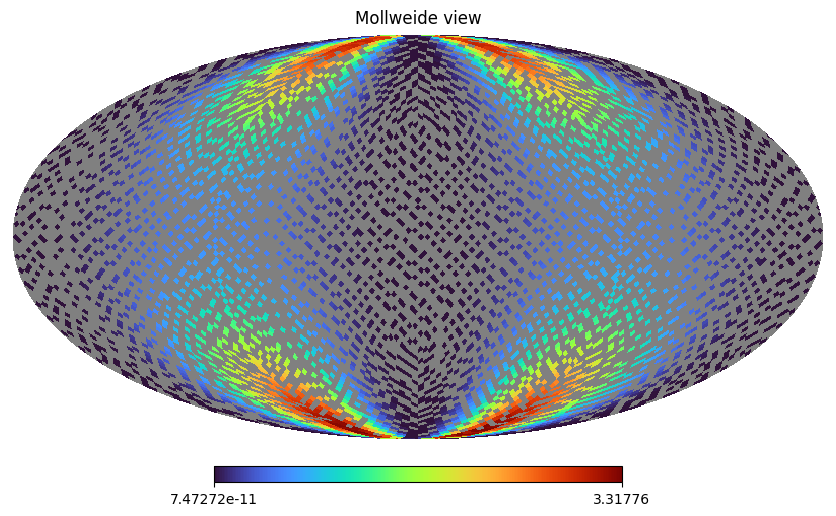

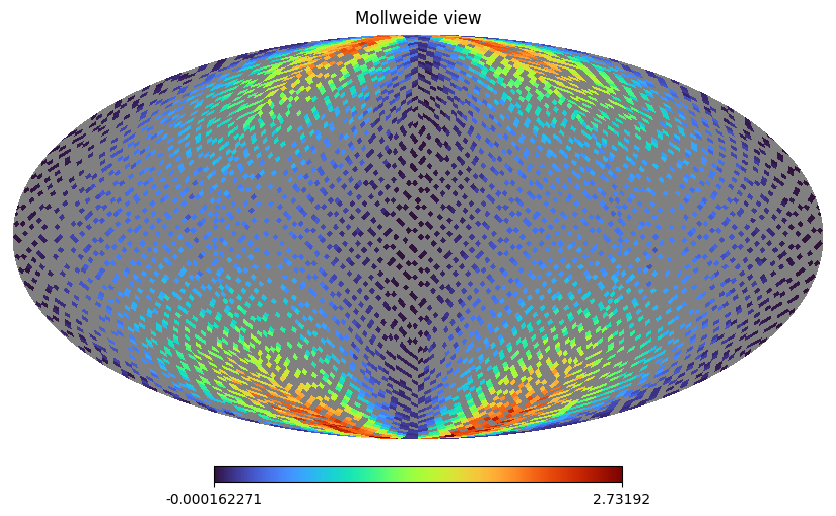

In [182]:
empty_map = jnp.full_like(DEFAULT_BEAM_PHI, fill_value=hp.UNSEEN)
test_map = empty_map.at[arc_pxs].set(test_data)

beam_proj(arc_pxs, P_E_noplf, vmin=None, vmax=None)
hp.mollview(test_map, cmap='turbo')

0.6385234065071226


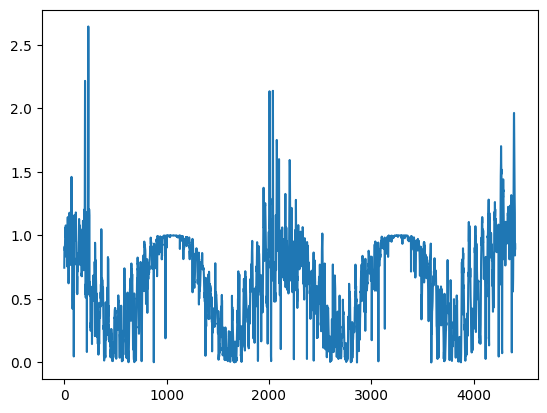

In [144]:
# plt.figure()
# plt.plot(test_data - P_E_noplf)
# plt.show()
scale = jnp.nanmedian(test_data / P_E_noplf)
P_model_scaled = scale * P_E_noplf
frac_err = np.abs(P_model_scaled - test_data) / test_data
max_mask = np.isin(frac_err, np.max(frac_err))
min_mask = np.isin(frac_err, np.min(frac_err))
print(np.mean(frac_err))
plt.figure()
plt.plot(frac_err[~min_mask])
plt.show()

0.3516433214707697


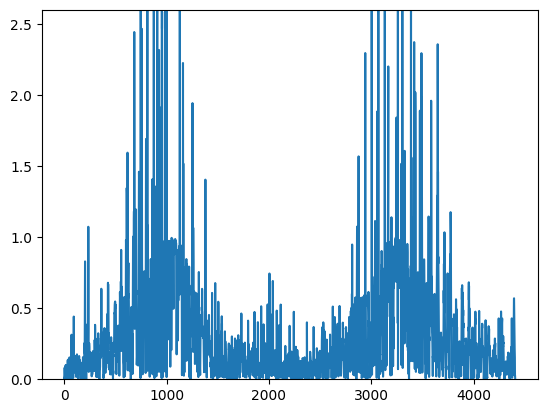

In [150]:

# plt.figure()
# plt.plot(test_data - P_E_noplf)
# plt.show()
scale = jnp.nanmedian(test_data / P_E_noplf)
P_model_scaled = scale * P_E_noplf
frac_err = np.abs(P_model_scaled - test_data) / test_data
print(np.mean(frac_err))
max_mask = np.isin(frac_err, np.max(frac_err))
min_mask = np.isin(frac_err, np.min(frac_err))
plt.figure()
plt.plot(frac_err[~max_mask& ~min_mask])
plt.ylim(0, 2.6)
plt.show()